# Report

**Group name:** Timo & Jakub

**Student names & numbers:**
* Timo Storny - 00099699
* Jakub Holik - 00099393


---

## 0. Iteration setup

**Import libraries**

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import seaborn as sns
import rasterio
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

**Load datasets**

This study uses multiple datasets from reliable scientific and governmental sources. Weather data were obtained from the Royal Netherlands Meteorological Institute (KNMI), including measurements such as temperature, wind, precipitation, and radiation from several coastal stations in the Netherlands. Environmental data were sourced from Statistics Netherlands (CBS), specifically ecosystem type maps covering the period 2013–2022. In addition, species occurrence data for Clupea harengus (Atlantic herring) were retrieved from the Global Biodiversity Information Facility (GBIF), an international open-access biodiversity database.

In [93]:
df_clupea = pd.read_csv('Clupea harengus.csv', low_memory=False)
df_weather = pd.read_csv('knmi_weather_data.csv')
df_env = pd.read_csv('habitats_cbs_2022.csv')

In [ ]:
df_clupea['eventDate'] = pd.to_datetime(df_clupea['eventDate'], format='%Y-%m-%d')
df_clupea['Clupea harengus'] = pd.to_numeric(df_clupea['Clupea harengus'], errors='coerce')
print("General information:")
df_clupea.info()

print("\n\nAmount of null's in each column:")
print(df_clupea.isnull().sum())

print("\n\nStatistical summary:")
df_clupea.describe()


General information:
<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Clupea harengus            float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 574.9 MB


Amount of null's in each column:
decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           1
speciesgroup_observations    0
Clupea harengus              4
dtype: int64


Statistical summary:


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Clupea harengus
count,1.255879e+07,1.255879e+07,12558786,1.255878e+07,1.255879e+07,1.255878e+07
mean,5.222995e+01,5.532896e+00,2017-12-31 12:10:06.165595,8.134787e+00,8.965699e-02,4.266337e-04
min,3.500000e+00,3.350000e+00,2010-01-01 00:00:00,0.000000e+00,0.000000e+00,-1.000000e+00
25%,5.170000e+01,4.900000e+00,2014-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.220000e+01,5.650000e+00,2018-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
75%,5.280000e+01,6.200000e+00,2022-01-01 00:00:00,6.000000e+00,0.000000e+00,0.000000e+00
max,5.350000e+01,5.340000e+01,2026-01-30 00:00:00,1.000400e+05,1.011000e+03,1.370000e+02
std,6.647267e-01,8.779710e-01,NaN,5.593995e+01,2.514183e+00,6.192660e-02


In [95]:
print("General information:")
df_env.info()

print("\n\nAmount of null's in each column:")
print(df_env.isnull().sum())

print("\n\nStatistical summary:")
df_env.describe()

General information:
<class 'pandas.DataFrame'>
RangeIndex: 2179 entries, 0 to 2178
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   decimalLongitude  2179 non-null   float64
 1   decimalLatitude   2179 non-null   float64
 2   agricultural      2179 non-null   float64
 3   built             2179 non-null   float64
 4   coast             2179 non-null   float64
 5   forest            2179 non-null   float64
 6   other             2179 non-null   float64
 7   sand/heather      2179 non-null   float64
 8   water             2179 non-null   float64
 9   wetland           2179 non-null   float64
 10  main_habitat      2179 non-null   str    
dtypes: float64(10), str(1)
memory usage: 187.4 KB


Amount of null's in each column:
decimalLongitude    0
decimalLatitude     0
agricultural        0
built               0
coast               0
forest              0
other               0
sand/heather        0
water     

,decimalLongitude,decimalLatitude,agricultural,built,coast,forest,other,sand/heather,water,wetland
count,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000
mean,5.510624,52.242336,9.571166,2.600712,1.510309,1.816148,1.716892,0.405040,1.461374,0.414471
std,0.890036,0.664786,5.303015,3.053375,4.443380,3.040838,2.366745,2.245601,3.402881,2.089655
min,3.350000,50.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.850000,51.700000,5.394250,0.780050,0.000000,0.153250,0.735300,0.000000,0.102800,0.000000
50%,5.650000,52.200000,10.623900,1.584300,0.000000,0.735100,1.213500,0.000000,0.318300,0.019300
75%,6.150000,52.800000,13.883000,3.391350,0.000000,2.123850,2.042500,0.027000,1.096200,0.157850
max,7.200000,53.500000,29.522800,29.835000,28.982000,28.075200,29.906000,29.408500,29.863600,28.847500


In [96]:
str_columns = df_weather.select_dtypes(include=['object', 'string']).columns

for col in str_columns:
    df_weather[col] = pd.to_numeric(df_weather[col], errors='coerce')

df_weather['Date'] = pd.to_datetime(df_weather['Date'], format='%Y%m%d')

df_weather = df_weather.replace(r'^\s*$', pd.NA, regex=True)

print("General information:")
df_weather.info()

print("\n\nAmount of null's in each column:")
print(df_weather.isna().sum())

print("\n\nStatistical summary:")
df_weather.describe()

General information:
<class 'pandas.DataFrame'>
RangeIndex: 71784 entries, 0 to 71783
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Station                        71784 non-null  int64         
 1   Date                           71784 non-null  datetime64[us]
 2   vector_mean_direction_degrees  70421 non-null  float64       
 3   vector_mean_windspeed          70421 non-null  float64       
 4   windspeed                      70514 non-null  float64       
 5   windgust                       70498 non-null  float64       
 6   temp_mean                      35855 non-null  float64       
 7   temp_min                       35855 non-null  float64       
 8   temp_max                       35855 non-null  float64       
 9   sun_dur                        29906 non-null  float64       
 10  per_max_pot_sun_dur            29906 non-null  float64       
 11  globa

,Station,Date,vector_mean_direction_degrees,vector_mean_windspeed,windspeed,windgust,temp_mean,temp_min,temp_max,sun_dur,per_max_pot_sun_dur,global_radiation,precipitation_dur,precipitation,cloud_cover
count,71784.000000,71784,70421.000000,70421.000000,70514.000000,70498.000000,35855.000000,35855.000000,35855.000000,29906.000000,29906.000000,29906.000000,29907.000000,29907.000000,19291.000000
mean,274.750000,2018-03-10 12:00:00,190.671490,59.356769,67.406132,132.244319,109.198857,80.477925,137.794338,53.724069,41.440012,1107.955527,17.106697,22.103454,5.686693
min,209.000000,2010-01-01 00:00:00,1.000000,0.000000,10.000000,30.000000,-114.000000,-176.000000,-67.000000,-1.000000,0.000000,22.000000,0.000000,-1.000000,0.000000
25%,240.250000,2014-02-04 00:00:00,110.000000,36.000000,45.000000,100.000000,67.000000,42.000000,89.000000,14.000000,13.000000,337.250000,0.000000,0.000000,4.000000
50%,281.000000,2018-03-10 12:00:00,210.000000,56.000000,63.000000,120.000000,106.000000,79.000000,135.000000,48.000000,40.000000,935.000000,2.000000,1.000000,6.000000
75%,310.500000,2022-04-14 00:00:00,258.000000,79.000000,85.000000,160.000000,156.000000,125.000000,188.000000,87.000000,68.000000,1770.000000,24.000000,24.000000,8.000000
max,330.000000,2026-05-18 00:00:00,360.000000,202.000000,203.000000,480.000000,303.000000,236.000000,389.000000,157.000000,95.000000,3180.000000,240.000000,780.000000,8.000000
std,39.132793,NaN,95.306002,30.438256,28.593083,47.734481,57.372641,54.645667,64.412893,43.248569,30.372459,838.851918,28.085692,45.114325,2.241838


| Station | LON (east) | LAT (north) | ALT (m) | Name               |
| ------- | ---------- | ----------- | ------- | ------------------ |
| 209     | 4.518      | 52.465      | 0.00    | IJmond             |
| 225     | 4.555      | 52.463      | 4.40    | IJmuiden           |
| 235     | 4.781      | 52.928      | 1.20    | De Kooy Airport    |
| 242     | 4.921      | 53.241      | 10.80   | Vlieland Vliehors  |
| 251     | 5.346      | 53.392      | 0.70    | Hoorn Terschelling |
| 277     | 6.200      | 53.413      | 2.90    | Lauwersoog         |
| 285     | 6.399      | 53.575      | 0.00    | Huibertgat         |
| 308     | 3.379      | 51.381      | 0.00    | Cadzand            |
| 310     | 3.596      | 51.442      | 8.00    | Vlissingen         |
| 312     | 3.622      | 51.768      | 0.00    | Oosterschelde      |
| 313     | 3.242      | 51.505      | 0.00    | Vlakte van De Raan |
| 330     | 4.122      | 51.992      | 11.90   | Hoek van Holland   |

In [97]:
df_weather = df_weather.ffill()
df_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 71784 entries, 0 to 71783
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Station                        71784 non-null  int64         
 1   Date                           71784 non-null  datetime64[us]
 2   vector_mean_direction_degrees  71784 non-null  float64       
 3   vector_mean_windspeed          71784 non-null  float64       
 4   windspeed                      71784 non-null  float64       
 5   windgust                       71784 non-null  float64       
 6   temp_mean                      71784 non-null  float64       
 7   temp_min                       71784 non-null  float64       
 8   temp_max                       71784 non-null  float64       
 9   sun_dur                        71784 non-null  float64       
 10  per_max_pot_sun_dur            71784 non-null  float64       
 11  global_radiation          

---

## 1. Business Understanding (The Ecology / Project Goal)
In an academic data science project using the herring habitat dataset, "business understanding" translates to your ecological objective. 
- **Background:** Briefly explain why modeling the habitat of *Clupea harengus* matters (e.g., understanding spawning grounds, tracking population shifts due to environment, etc.).
- **Problem Statement:** What question are you answering? For example: *"Can we predict the presence or abundance of Atlantic herring based on the percentage of different habitat types (e.g., coastal, water, agricultural) in a given area?"* [exxactcorp](https://www.exxactcorp.com/blog/deep-learning/simple-steps-for-data-preparation-exploratory-data-analysis)
- **Data Management Goals (DMGs):** This is the technical translation of your problem. What exact modeling task will you perform? State whether it is a classification task (e.g., predicting presence vs. absence) or a regression task (e.g., predicting observation counts). Define your target variable and your predictor variables.
- **Success Criteria:** How will you know if your model is "good"? Define the metric you will use (e.g., "Achieve an F1-score above 0.70" or "Beat a baseline logistic regression model by 15% accuracy"). [sites.gatech](https://sites.gatech.edu/omscs7641/2026/01/26/eda-for-cs7641/)

## 2. Initial Exploratory Data Analysis (EDA)
EDA is how you prove you have inspected the data before blindly throwing algorithms at it. You do not need perfect, highly-polished charts yet; the goal is to show you understand the dataset's shape, quality, and patterns. [linkedin](https://www.linkedin.com/pulse/exploratory-data-analysis-eda-visual-guide-before-niaz-chowdhury-phd-2d6qe)

Include the following steps and visuals in your EDA:
- **Data Overview:** Report the shape of your dataset (number of rows and columns) and list the features (e.g., `decimalLongitude`, `decimalLatitude`, `coast`, `forest`, `agricultural`, etc.). [sites.gatech](https://sites.gatech.edu/omscs7641/2026/01/26/eda-for-cs7641/)
- **Data Quality Check:** Show that you have checked for missing values (NaNs), duplicates, and incorrect data types. Mention how you plan to handle any issues you found (e.g., "We will drop 12 rows with missing coordinates"). [linkedin](https://www.linkedin.com/pulse/exploratory-data-analysis-eda-visual-guide-before-niaz-chowdhury-phd-2d6qe)
- **Univariate Analysis (Distributions):** Look at variables one at a time.
  - Plot a histogram or bar chart of your target variable. Is it imbalanced? (e.g., Are there 10,000 "presence" rows but only 500 "absence" rows?)
  - Plot histograms for key predictors (like the percentage of `coast` or `water` habitat). [kaggle](https://www.kaggle.com/questions-and-answers/412077)
- **Bivariate/Multivariate Analysis (Relationships):** Look at how variables interact.
  - Show a correlation heatmap of the numerical features. This will show if variables are highly correlated (e.g., maybe `coast` and `water` are multicollinear and you shouldn't use both). [linkedin](https://www.linkedin.com/pulse/exploratory-data-analysis-eda-visual-guide-before-niaz-chowdhury-phd-2d6qe)
  - Create boxplots or violin plots showing the distribution of specific habitat types split by your target variable (e.g., "Percentage of Coastal Habitat vs. Herring Presence"). [kaggle](https://www.kaggle.com/questions-and-answers/412077)
- **Spatial Plot (Optional but highly recommended):** Since you have coordinates (`decimalLongitude`, `decimalLatitude`), plot your data points on a scatter plot or a map. This is a massive bonus for an ecological dataset and immediately shows if herring are clustering in specific regions.

Finish your check-in with a short **conclusion/next steps** section stating your data is viable and what preprocessing (scaling, imputation, feature engineering) you will do next based on your EDA. 

---

### Data Understanding

In [ ]:
# Merge environmental data
df_merged = pd.merge(
    df_clupea,
    df_env,
    on=['decimalLatitude', 'decimalLongitude'],
    how='left'
)

# Aggregate weather by day first
weather_daily = df_weather.groupby('Date').mean(numeric_only=True).reset_index()

# Merge weather data
df_merged = pd.merge(
    df_merged,
    weather_daily,
    left_on='eventDate',
    right_on='Date',
    how='left'
)

df_merged_to = df_merged[df_merged['total_observations'].fillna(0) != 0]
df_merged_so = df_merged[df_merged['speciesgroup_observations'].fillna(0) != 0]
df_merged_ch = df_merged[df_merged['Clupea harengus'].fillna(0) != 0]


df_merged.info()Data understanding (Weather)

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 32 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   decimalLatitude                float64       
 1   decimalLongitude               float64       
 2   eventDate                      datetime64[us]
 3   total_observations             float64       
 4   speciesgroup_observations      int64         
 5   Clupea harengus                float64       
 6   year                           int32         
 7   season                         str           
 8   agricultural                   float64       
 9   built                          float64       
 10  coast                          float64       
 11  forest                         float64       
 12  other                          float64       
 13  sand/heather                   float64       
 14  water                          float64       
 15  wetland                 

In [122]:
df_merged.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Clupea harengus,agricultural,built,coast,forest,...,windgust,temp_mean,temp_min,temp_max,sun_dur,per_max_pot_sun_dur,global_radiation,precipitation_dur,precipitation,cloud_cover
0,50.75,5.65,2010-01-01,0.0,0,0.0,1.7747,0.0568,0.0,0.0616,...,135.000000,59.666667,28.250000,84.833333,74.750000,60.583333,1420.750000,1.916667,2.250000,4.777778
1,50.75,5.65,2010-01-02,26.0,0,0.0,1.7747,0.0568,0.0,0.0616,...,122.500000,56.666667,29.750000,82.333333,57.666667,38.583333,1336.666667,21.750000,26.083333,6.333333
2,50.75,5.65,2010-01-03,3.0,0,0.0,1.7747,0.0568,0.0,0.0616,...,131.666667,50.500000,18.416667,80.250000,75.250000,61.000000,1422.000000,10.000000,6.250000,5.111111
3,50.75,5.65,2010-01-04,0.0,0,0.0,1.7747,0.0568,0.0,0.0616,...,107.500000,62.750000,28.333333,92.916667,61.750000,43.916667,1360.666667,11.250000,11.833333,6.111111
4,50.75,5.65,2010-01-05,0.0,0,0.0,1.7747,0.0568,0.0,0.0616,...,102.500000,65.666667,42.916667,88.916667,60.916667,42.583333,1352.916667,14.416667,12.750000,6.111111


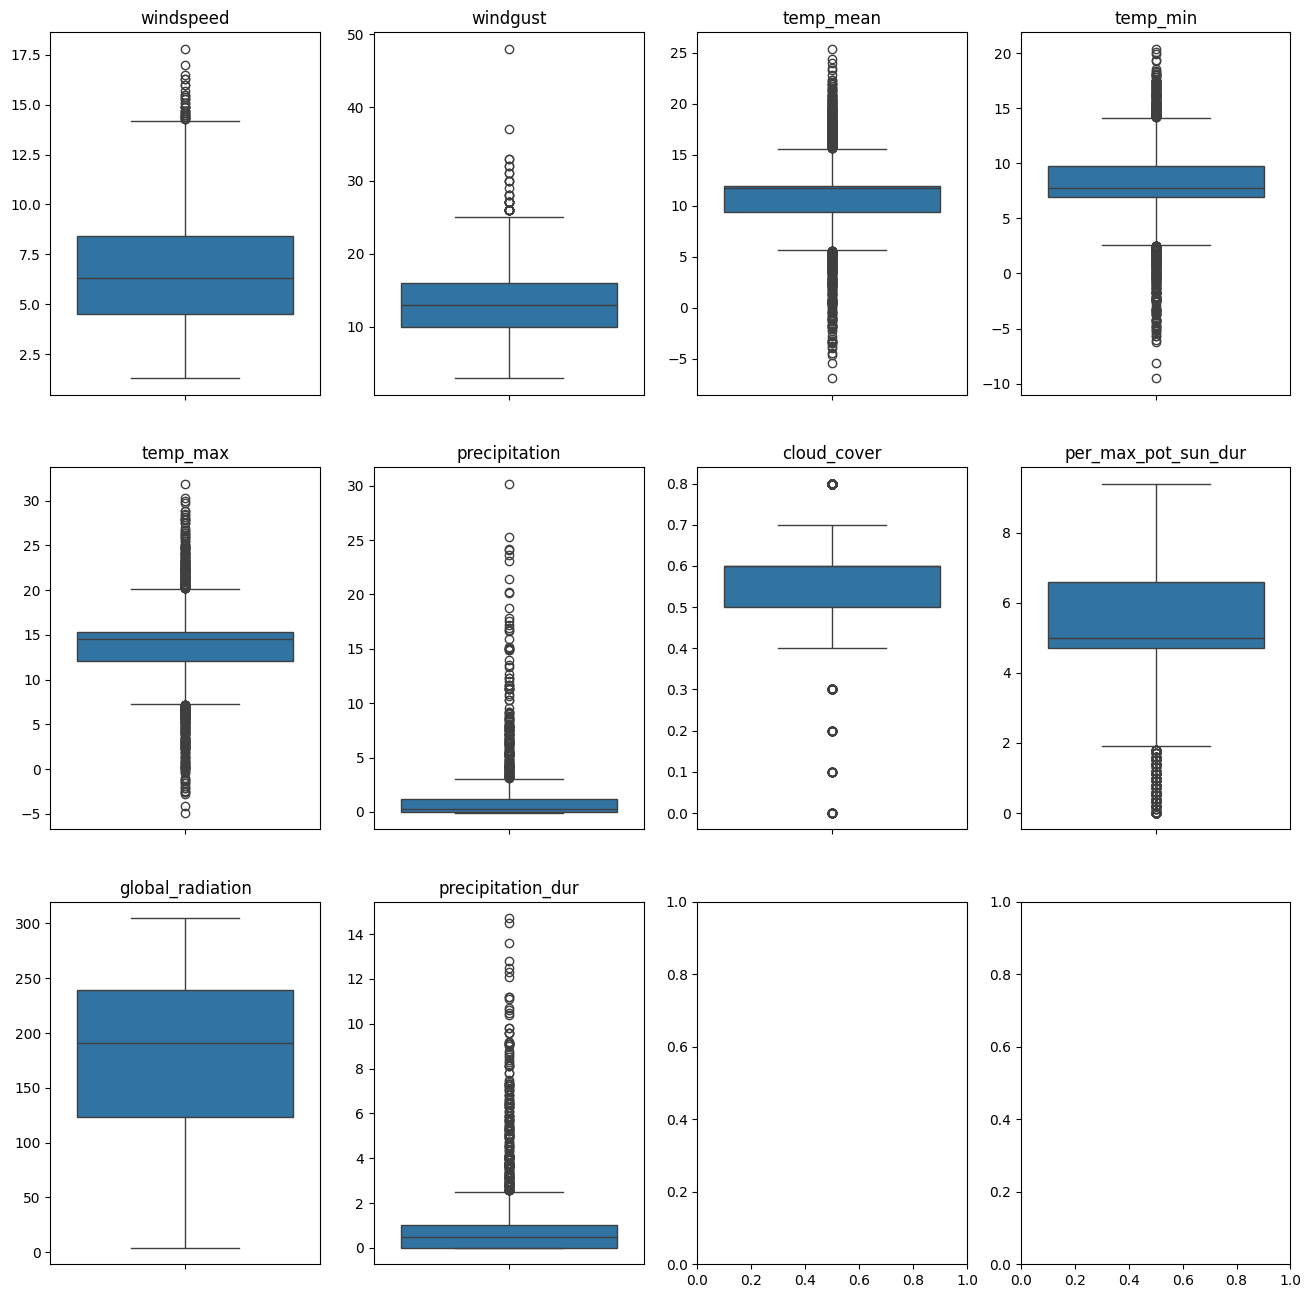

In [100]:
weather_cols = [
    'windspeed',
    'windgust',
    'temp_mean',
    'temp_min',
    'temp_max',
    'precipitation',
    'cloud_cover',
    'per_max_pot_sun_dur',	'global_radiation',	'precipitation_dur'	
]

for col in weather_cols:
    df_weather[col] = pd.to_numeric(df_weather[col], errors='coerce') / 10

df_weather_small = df_weather[weather_cols]

weather_sample = df_weather[weather_cols].dropna().sample(
    n=min(2000, len(df_weather[weather_cols].dropna())),
    random_state=42
)

fig, axes = plt.subplots(3, 4, figsize=(16, 16))

axes = axes.flatten()

for i, col in enumerate(weather_cols):
    sns.boxplot(
        y=weather_sample[col],
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_ylabel('')
    
plt.show()

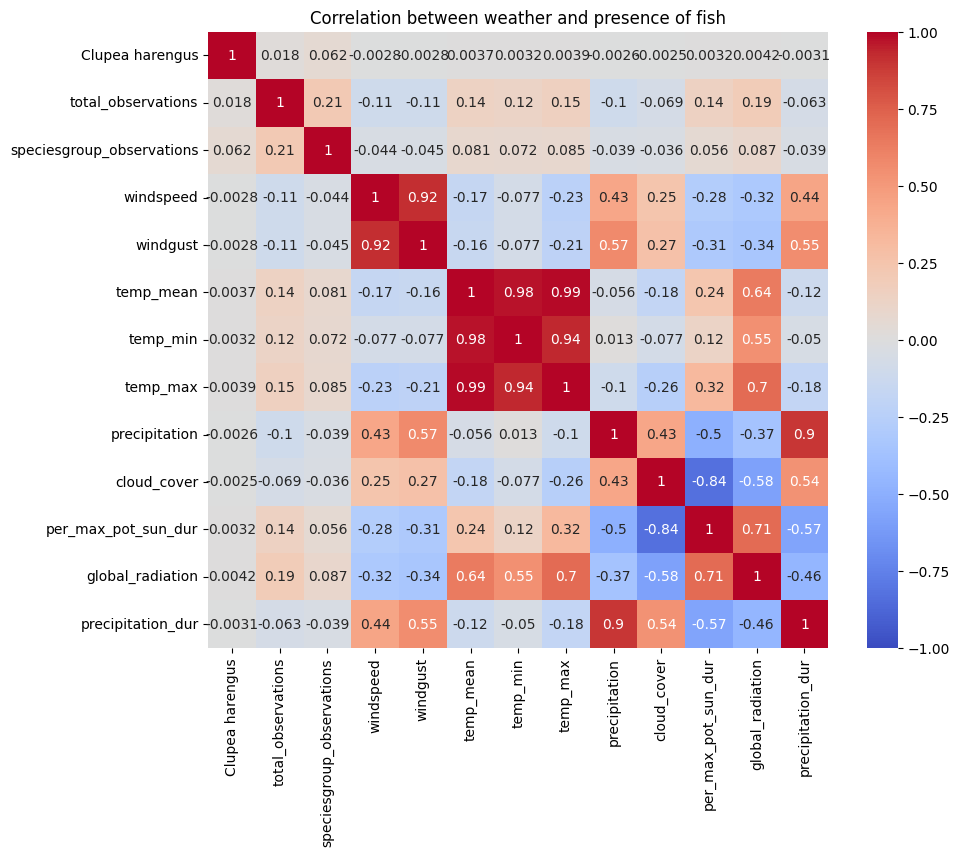

In [110]:


corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'windspeed',
    'windgust',
    'temp_mean',
    'temp_min',
    'temp_max',
    'precipitation',
    'cloud_cover',
    'per_max_pot_sun_dur',	'global_radiation',	'precipitation_dur'	
]

corr_df = df_merged[corr_cols]

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_df.corr(method='spearman'),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True
)

plt.title('Correlation between weather and presence of fish')
plt.show()

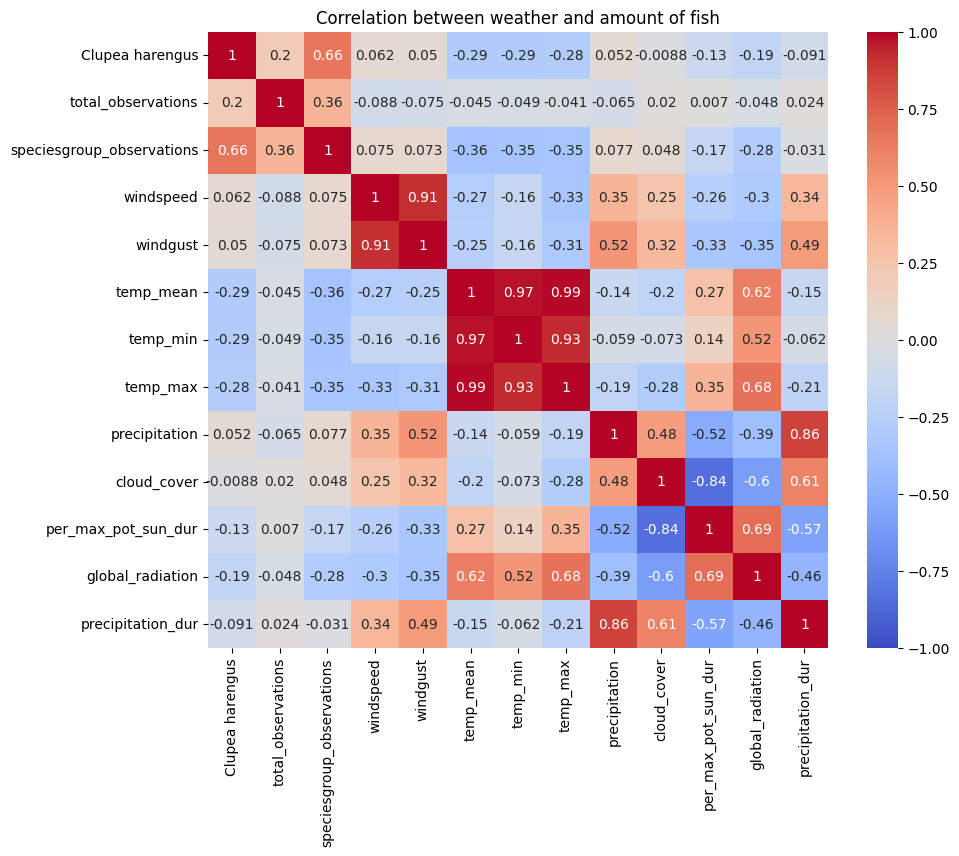

In [109]:


corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'windspeed',
    'windgust',
    'temp_mean',
    'temp_min',
    'temp_max',
    'precipitation',
    'cloud_cover',
    'per_max_pot_sun_dur',	'global_radiation',	'precipitation_dur'	
]

corr_df = df_merged_ch[corr_cols]

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_df.corr(method='spearman'),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True
)

plt.title('Correlation between weather and amount of fish')
plt.show()

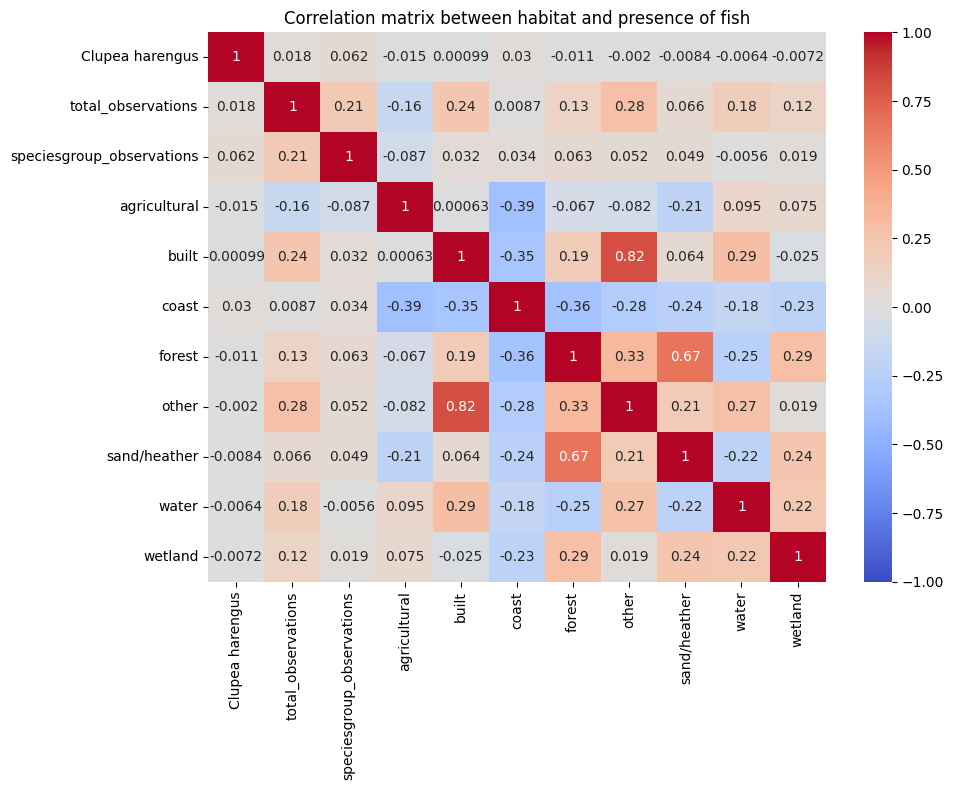

In [119]:
corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'agricultural',
    'built',
    'coast',
    'forest',
    'other',
    'sand/heather',
    'water',
    'wetland'
]

corr_df = df_merged[corr_cols].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_df.corr(method='spearman'),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True
)

plt.title('Correlation matrix between habitat and presence of fish')
plt.tight_layout()
plt.show()

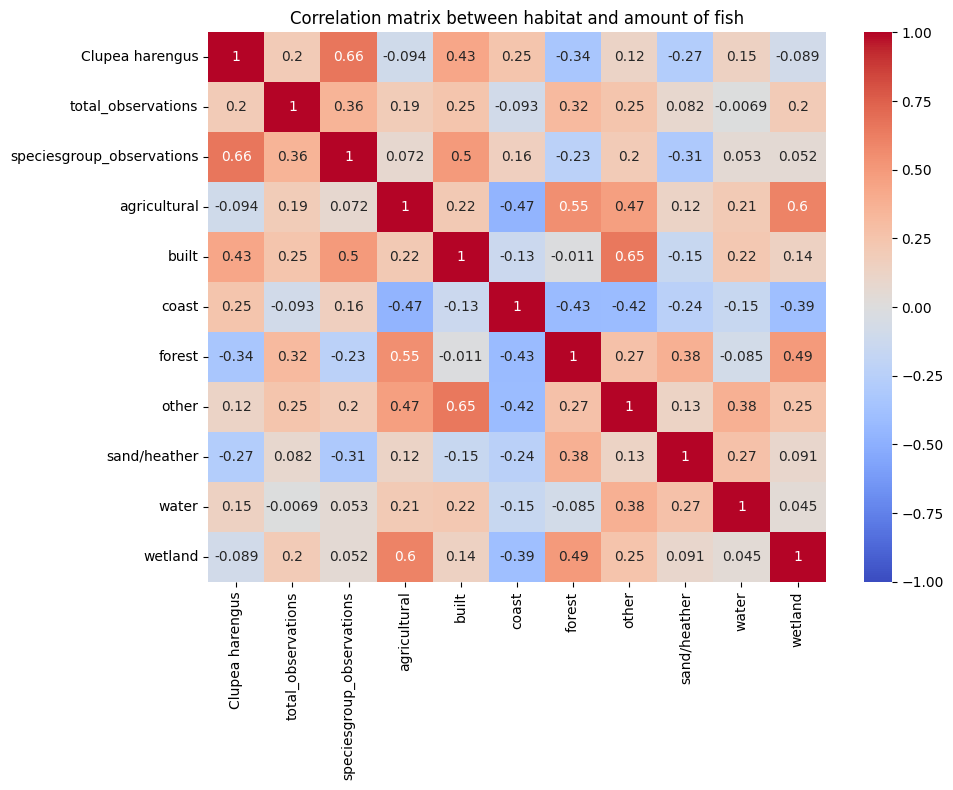

In [120]:
corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'agricultural',
    'built',
    'coast',
    'forest',
    'other',
    'sand/heather',
    'water',
    'wetland'
]

corr_df = df_merged_ch[corr_cols].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_df.corr(method='spearman'),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True
)

plt.title('Correlation matrix between habitat and amount of fish')
plt.tight_layout()
plt.show()

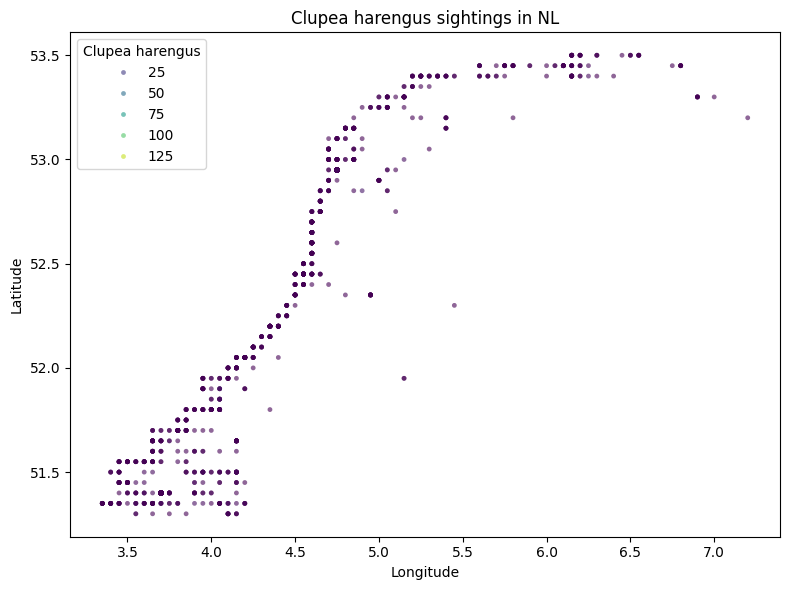

In [ ]:
loc_sample = df_merged_ch[
    (df_merged_ch['Clupea harengus']>0) &
    (df_merged_ch['decimalLongitude'].between(3.0, 7.5)) &
    (df_merged_ch['decimalLatitude'].between(50.5, 53.7))
][['decimalLongitude', 'decimalLatitude', 'Clupea harengus']].dropna()

loc_sample = loc_sample.sample(
    n=min(2000, len(loc_sample)),
    random_state=69
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=loc_sample,
    x='decimalLongitude',
    y='decimalLatitude',
    hue='Clupea harengus',
    palette='viridis',
    s=12,
    alpha=0.6,
    linewidth=0
)

plt.title('Clupea harengus sightings in NL')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.tight_layout()
plt.show()

No correlation

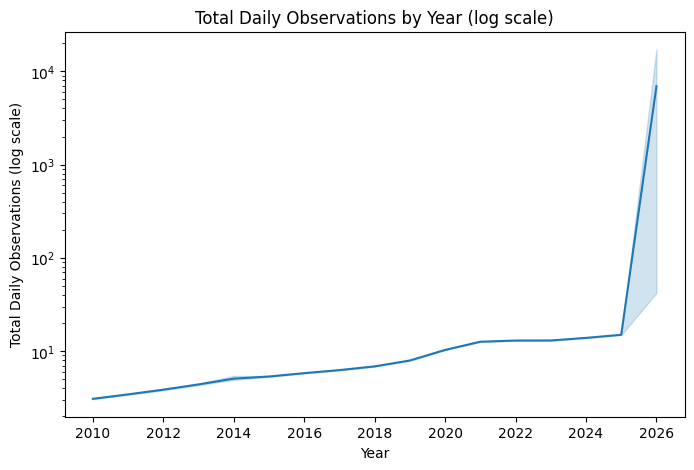

In [116]:
df_clupea['year'] = df_clupea['eventDate'].dt.year
year_counts = df_clupea['year'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_clupea,
    x='year',
    y='total_observations'
)

plt.yscale('log')

plt.title('Total Daily Observations by Year (log scale)')
plt.ylabel('Total Daily Observations (log scale)')
plt.xlabel('Year')

plt.show()

No temporal bias

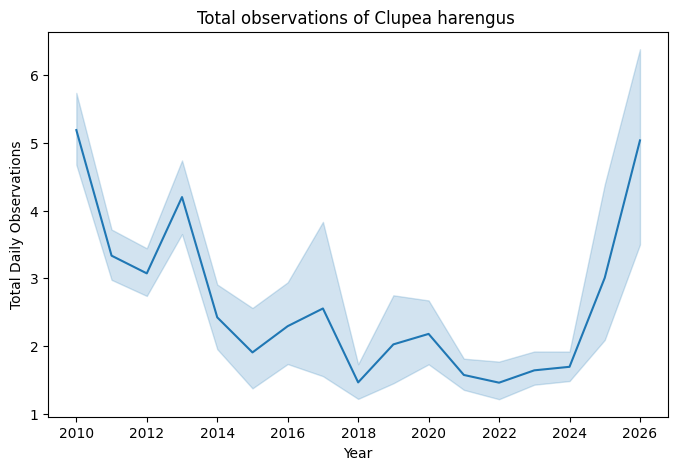

In [117]:
df_merged_ch['year'] = df_merged_ch['eventDate'].dt.year
year_counts = df_merged_ch['year'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_merged_ch,
    x='year',
    y='Clupea harengus'
)

# plt.yscale('log')

plt.title('Total observations of Clupea harengus ')
plt.ylabel('Total Daily Observations')
plt.xlabel('Year')

plt.show()

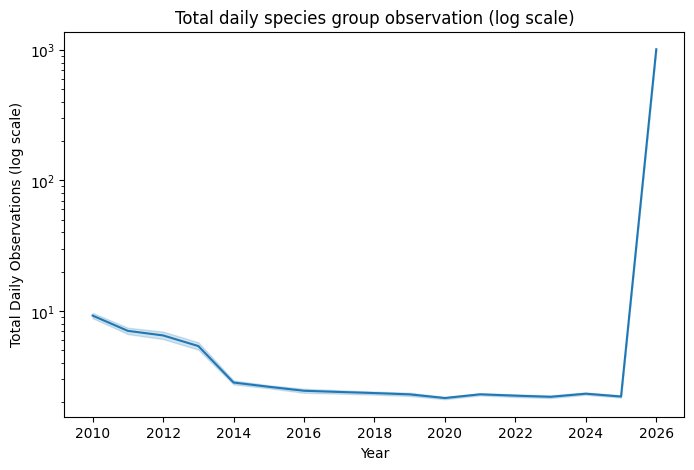

In [118]:
df_merged_so['year'] = df_merged_so['eventDate'].dt.year
year_counts = df_merged_so['year'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_merged_so,
    x='year',
    y='speciesgroup_observations'
)

plt.yscale('log')

plt.title('Total daily species group observation (log scale)')
plt.ylabel('Total Daily Observations (log scale)')
plt.xlabel('Year')

plt.show()

The yearly distribution of total daily observations shows a strong right-skewed pattern with numerous extreme outliers across all years. Observation magnitudes and variability appear to increase over time, particularly after 2018. This may reflect changes in ecological conditions, sampling intensity, or reporting practices. The logarithmic scale was necessary to visualize both small and extremely large observation counts simultaneously.

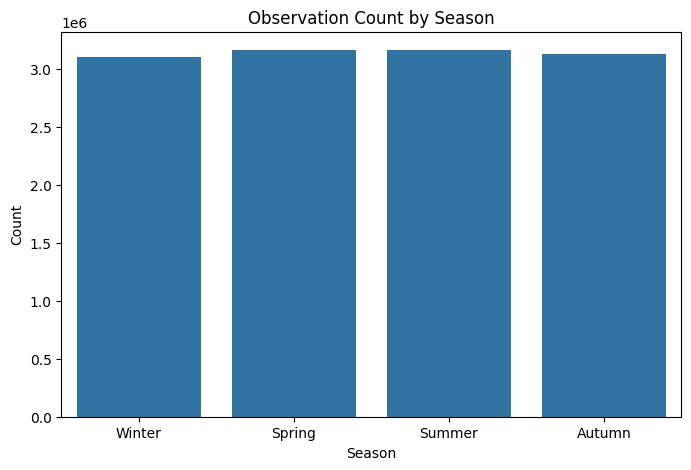

In [106]:
df_clupea['season'] = df_clupea['eventDate'].dt.month.map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

season_counts = df_clupea['season'].value_counts()

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_order,
    y=[season_counts[s] for s in season_order]
)

plt.title('Observation Count by Season')
plt.ylabel('Count')
plt.xlabel('Season')

plt.show()

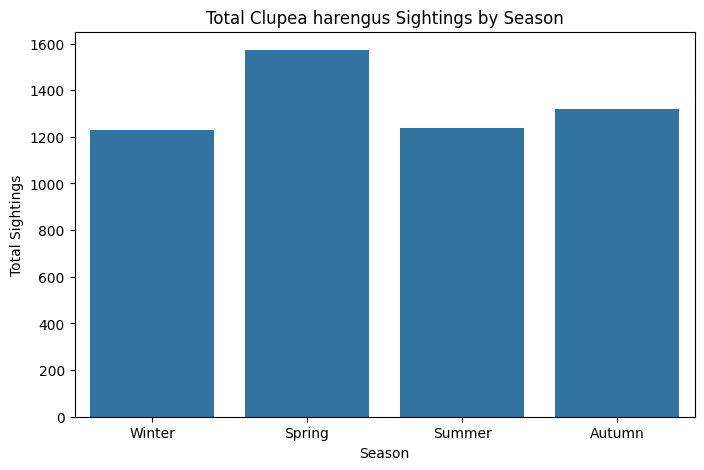

In [107]:
# Create season column
df_clupea['season'] = df_clupea['eventDate'].dt.month.map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# Sum total herring sightings per season
season_sightings = df_clupea.groupby('season')['Clupea harengus'].sum()

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

# Plot
plt.figure(figsize=(8,5))

sns.barplot(
    x=season_order,
    y=[season_sightings[s] for s in season_order]
)

plt.title('Total Clupea harengus Sightings by Season')
plt.ylabel('Total Sightings')
plt.xlabel('Season')

plt.show()

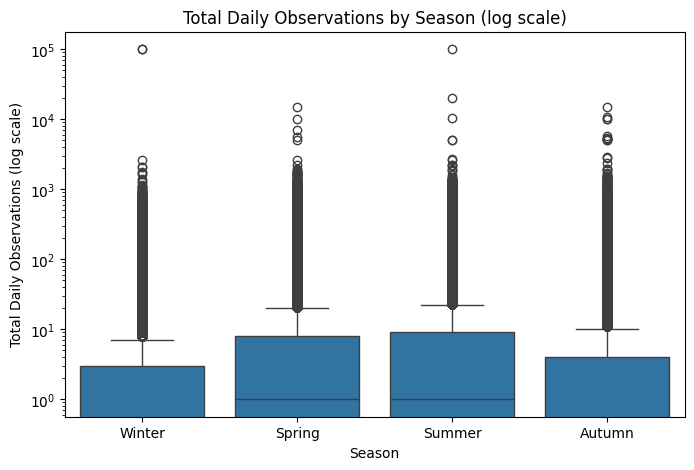

In [108]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clupea,
    x='season',
    y='total_observations'
)

plt.yscale('log')

plt.title('Total Daily Observations by Season (log scale)')
plt.ylabel('Total Daily Observations (log scale)')
plt.xlabel('Season')

plt.show()

The seasonal distributions of total observations appear highly right-skewed, with most values concentrated near zero and several extreme outliers present across all seasons. No strong seasonal imbalance is immediately visible, although summer contains some of the largest observation counts.

In [124]:
df_merged_ch.info()

<class 'pandas.DataFrame'>
Index: 2041 entries, 748653 to 12558785
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   decimalLatitude                2041 non-null   float64       
 1   decimalLongitude               2041 non-null   float64       
 2   eventDate                      2041 non-null   datetime64[us]
 3   total_observations             2040 non-null   float64       
 4   speciesgroup_observations      2041 non-null   int64         
 5   Clupea harengus                2041 non-null   float64       
 6   year                           2041 non-null   int32         
 7   season                         2041 non-null   str           
 8   agricultural                   2015 non-null   float64       
 9   built                          2015 non-null   float64       
 10  coast                          2015 non-null   float64       
 11  forest                  